Import all requires library and utils

In [36]:
import copy
import json
import random
import time
import math
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset, Dataset

import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.5.1+cu121
0.20.1+cu121


Configs class

In [2]:
@dataclass(slots=True)
class Config:
    model_name: str = ""
    data_dir: str = "./data"
    fast_mode: bool = False
    batch_size: int = 32
    n_show: int = 10
    seed: int = 42
    
cfg = Config()
cfg

Config(model_name='', data_dir='./data', fast_mode=False, batch_size=32, n_show=10, seed=42)

Function that fix the seed

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(cfg.seed)

Define the device and quantity of epochs

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print('device: ', device)

EPOCHS = 4 if cfg.fast_mode else 12
print('Epochs: ', EPOCHS)

RUNS = pd.DataFrame(
    columns=[
        'experiment_id', 
        'task', 
        'dataset', 
        'seed', 
        'model_summary', 
        'optimizer',
        'lr',
        'epochs_trained',
        'best_val_accuracy',
        'test_accuracy',
        'notes',
    ]
)
print(RUNS)

device:  cuda
Epochs:  12
Empty DataFrame
Columns: [experiment_id, task, dataset, seed, model_summary, optimizer, lr, epochs_trained, best_val_accuracy, test_accuracy, notes]
Index: []


Loading dataset CIFAR100

In [15]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

def loading_cifar100_dataset(
        train_transform: torchvision.transforms,
        test_transform: torchvision.transforms,
        data_dir: str = cfg.data_dir,
) -> Tuple[Dataset, Dataset]:
    
    train_dataset = torchvision.datasets.CIFAR100(data_dir, train=True, download=True, transform=train_transform)
    test_dataset = torchvision.datasets.CIFAR100(data_dir, train=False, download=True, transform=test_transform)
    
    return train_dataset, test_dataset

default_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

ds_train, ds_test = loading_cifar100_dataset(
    default_transform,
    default_transform
)

class_names = ds_train.classes
print("len(class_names): ", len(class_names))
print("test len: ", len(ds_test))
print('Classes', class_names)

Files already downloaded and verified
Files already downloaded and verified
len(class_names):  100
test len:  10000
Classes ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'ta

Create function which separate train on train and val datasets

In [6]:
def make_loaders(
    ds_train: torch.utils.data.Dataset,
    ds_test: torch.utils.data.Dataset,
    seed: int = cfg.seed,
    fast_mode: bool = cfg.fast_mode,
    batch_size: int = cfg.batch_size,
    val_ratio: float = 0.2
):
    train_len = len(ds_train)
    val_len = int(train_len * val_ratio)
    train_len = train_len - val_len
    
    ds_train, ds_val = random_split(
        ds_train, 
        lengths=[train_len, val_len], 
        generator=torch.Generator().manual_seed(seed)
    )
    
    # Fast-mode
    if fast_mode:
        rng = np.random.RandomState(cfg.seed)
        
        train_idx = rng.choice(len(ds_train), size=min(6000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(1500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(1500, len(ds_test)), replace=False)
        
        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test
        
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(
    ds_train,
    ds_test,
)

batch = next(iter(train_loader))
x, y = batch
print("x: ", x.shape, x.dtype)
print("y: ", y.shape, y.dtype)

x:  torch.Size([32, 3, 32, 32]) torch.float32
y:  torch.Size([32]) torch.int64


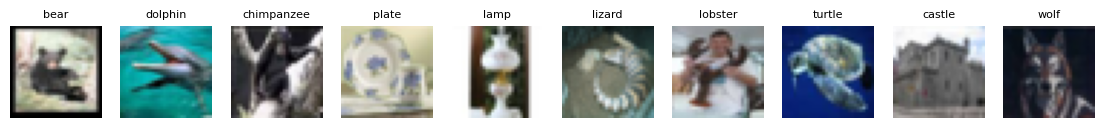

In [30]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(CIFAR100_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR100_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10, path_save: str = "") -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]
    
    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
        
    if path_save:
        plt.savefig(path_save)
    plt.show()
    
show_images(train_loader, n=cfg.n_show)

In [8]:
class CNNSimple(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 32 x 32 -> 32 x 32
            nn.ReLU(),
            nn.MaxPool2d(2), # 32 x 32 -> 16 x 16
        
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16 x 16 -> 16 x 16
            nn.ReLU(),
            nn.MaxPool2d(2), # 16 x 16 -> 8 x 8
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 8 x 8 -> 8 x 8
            nn.ReLU(),
            nn.MaxPool2d(2), # 8 x 8 -> 4 x 4
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x
        
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn_simple = CNNSimple(num_classes=len(class_names)).to(device=device)
print(cnn_simple)
print("Quantity of model's parameters: ", count_params(cnn_simple))

CNNSimple(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=100, bias=True)
  )
)
Quantity of model's parameters:  643492


Definite the main function like fit, evaluate, train_one_epoch and etc

In [83]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor):
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(
        loader: DataLoader,
        model: nn.Module,
        optimizer: optim,
        criterion: nn.Module,
) -> Tuple[float, float]:
    model.train()
    
    total_loss, total_correct, total_seen = 0, 0, 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        preds = model(x)
        loss = criterion(preds, y)
        
        if not torch.isfinite(loss):
            return float("nan"), float("nan")
        
        loss.backward()
        optimizer.step()
        
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(preds, dim=1) == y).sum().item()
        total_seen += bs
        
    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> Tuple[float, float] :
    model.eval()
    total_loss, total_accuracy, total_seen = 0, 0, 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        preds = model(x)
        loss = criterion(preds, y)
        
        if not torch.isfinite(loss):
            return float('nan'), float('nan')
        
        bs = y.size(0)
        
        total_loss += (loss.item() * bs)
        total_accuracy += (torch.argmax(preds, dim=1) == y).sum().item()
        total_seen += bs
        
    return total_loss / total_seen, total_accuracy / total_seen

def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: nn.Module,
    criterion: nn.Module,
    epochs: int = 4,
    verbose: bool = True,    
) -> Dict:
    
    history = {
        "train_acc": [],
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
    }
    
    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(
            train_loader,
            model,
            optimizer,
            criterion,
        )
        
        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
        )
        
        dt = time.time() - t0
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        if verbose:
            print(
                f"Epochs: {epoch + 1:02d}/{epochs:02d}, time: {dt:.1f}s | "
                f"Train Loss: {train_loss:.4f}, train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f}, val Acc: {val_acc:.4f}"
            )
        
        if not math.isfinite(train_loss) or (not math.isfinite(val_loss)):
            print("NaN/Inf in loss - feature of problems with LR/stability. Stop fitting.")
            break
        
    return history

def plot_history(history: Dict[str, List[float]], title: str = "", save_dir: str = "") -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(10, 8))
    plt.plot(epochs, history["train_loss"], label="train loss")
    plt.plot(epochs, history["val_loss"], label="val loss")
    plt.title(title + " Training Loss")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(False)    
    plt.show()
    
    plt.figure(figsize=(10, 8))
    plt.plot(epochs, history['train_acc'], label="train accuracy")
    plt.plot(epochs, history['val_acc'], label="val accuracy")
    plt.title(title + " Training Accuracy")
    plt.xlabel("epochs")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(False)
    plt.show()
    
def plot_best_history(
    history: Dict[str, List[float]],
    title: str = "",
    save_path: str | None = None,
) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    axes[0].plot(epochs, history["train_loss"], label="train loss")
    axes[0].plot(epochs, history["val_loss"], label="val loss")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("epochs")
    axes[0].set_ylabel("loss")
    axes[0].legend()
    axes[0].grid(False)

    axes[1].plot(epochs, history["train_acc"], label="train accuracy")
    axes[1].plot(epochs, history["val_acc"], label="val accuracy")
    axes[1].set_title(f"{title} Accuracy")
    axes[1].set_xlabel("epochs")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()
    axes[1].grid(False)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)
    
def run_experiment(
        experiment_id: str,
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        criterion: nn.Module,
        dataset: str,
        model_name: str,
        notes: Optional[str] = None,
        lr: float = 1e-3,
        weight_decay: float = 0.0,
        epochs: int = EPOCHS,
) -> Dict[str, Any]:
    
    model.to(device)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=lr, 
        weight_decay=weight_decay
    )
    
    print("\n" + "=" * 80)
    print(f"Experiment {experiment_id} | lr={lr}, weight_decay={weight_decay}, epochs={epochs}")
    print("Trainable parameters:", count_params(model))
    
    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs)
    best_val_acc = float(np.nanmax(hist['val_acc'])) if len(hist['val_acc']) else float("nan")
    
    return {
        "experiment_id": experiment_id,
        "model": model,
        "best_val_accuracy": best_val_acc,
        "history": hist,
        "optimizer": "Adam",
        "lr": lr,
        "epochs_trained": epochs,
        "dataset": dataset,
        "model_summary": model_name,
        "notes": notes,
    }

def save_to_runs(
        experiment_run: Dict,
        runs: pd.DataFrame,
    # experiment_id: str,
    # task: str,
    #     dataset: str,
    #     seed: int,
    #     model_summary: str,
    #     optimizer: str,
    #     lr: float,
    #     epochs_trained: int,
    #     best_val_accuracy: float,
    #     test_accuracy: float,
    #     notes: str,
) -> pd.DataFrame:
    
    drop_fields = ["model", "history"]
    
    filtered_run = {k: v for k, v in experiment_run.items() if k not in drop_fields}
    
    experiment_run = pd.DataFrame([filtered_run])
    return pd.concat([runs, experiment_run], ignore_index=True)
    
def save_runs(
        runs: pd.DataFrame,
        path: str,
):
    runs.to_csv(path, index=False)
    
def save_json(data: dict, path: str) -> None:
    if not path.endswith(".json"):
        raise ValueError("must be .json")

    with open(path, "w") as f:
        json.dump(data, f, indent=4)
    

In [38]:
criterion = nn.CrossEntropyLoss()


Experiment C1 | lr=0.001, weight_decay=0.0, epochs=12
Trainable parameters: 643492
Epochs: 01/12, time: 29.4s | Train Loss: 3.6362, train Acc: 0.1429 | Val Loss: 3.1145, val Acc: 0.2374
Epochs: 02/12, time: 27.2s | Train Loss: 2.8569, train Acc: 0.2827 | Val Loss: 2.7045, val Acc: 0.3149
Epochs: 03/12, time: 25.7s | Train Loss: 2.4547, train Acc: 0.3655 | Val Loss: 2.5095, val Acc: 0.3536
Epochs: 04/12, time: 26.0s | Train Loss: 2.1634, train Acc: 0.4295 | Val Loss: 2.4886, val Acc: 0.3708
Epochs: 05/12, time: 22.9s | Train Loss: 1.9380, train Acc: 0.4767 | Val Loss: 2.4187, val Acc: 0.3893
Epochs: 06/12, time: 23.3s | Train Loss: 1.7352, train Acc: 0.5252 | Val Loss: 2.4452, val Acc: 0.3828
Epochs: 07/12, time: 23.4s | Train Loss: 1.5413, train Acc: 0.5703 | Val Loss: 2.5931, val Acc: 0.3894
Epochs: 08/12, time: 22.7s | Train Loss: 1.3758, train Acc: 0.6090 | Val Loss: 2.6328, val Acc: 0.3946
Epochs: 09/12, time: 23.2s | Train Loss: 1.2231, train Acc: 0.6442 | Val Loss: 2.8003, val A

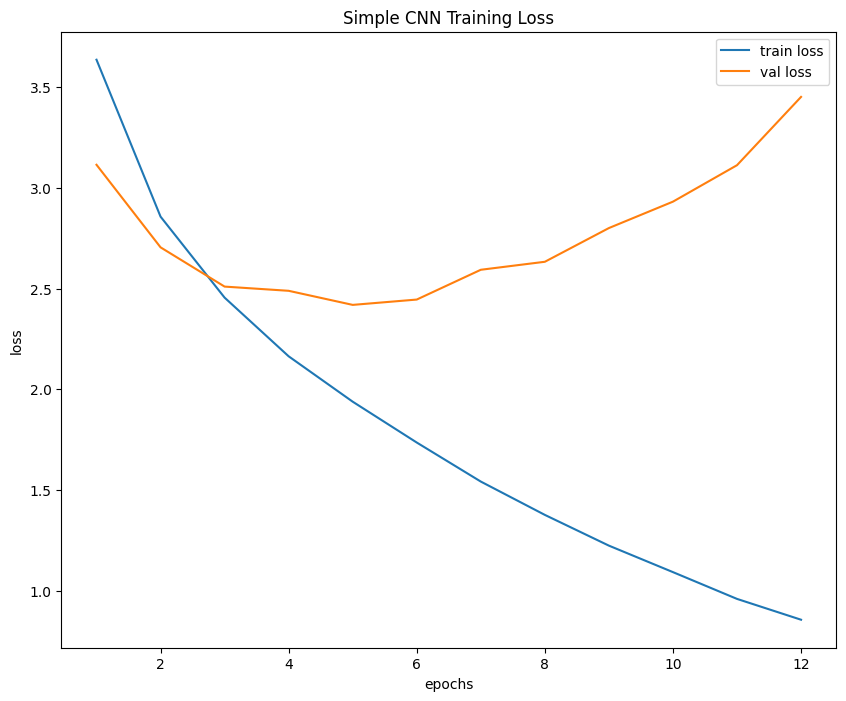

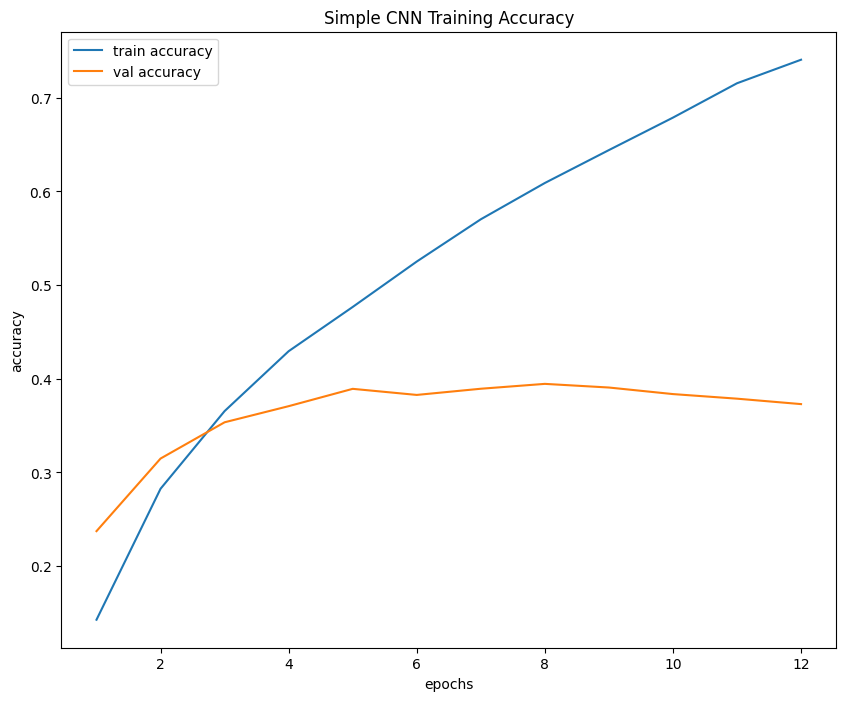

In [39]:
res_c1 = run_experiment(
    "C1",
    cnn_simple,
    train_loader,
    val_loader,
    criterion,
    dataset='cifar100',
    model_name="simple_cnn",
)
plot_history(res_c1["history"], title="Simple CNN")

Files already downloaded and verified
Files already downloaded and verified

Experiment C2 | lr=0.0001, weight_decay=0.0, epochs=12
Trainable parameters: 643492
Epochs: 01/12, time: 33.7s | Train Loss: 4.2259, train Acc: 0.0572 | Val Loss: 4.0050, val Acc: 0.0888
Epochs: 02/12, time: 34.0s | Train Loss: 3.8808, train Acc: 0.1069 | Val Loss: 3.7667, val Acc: 0.1279
Epochs: 03/12, time: 33.6s | Train Loss: 3.6905, train Acc: 0.1382 | Val Loss: 3.6363, val Acc: 0.1559
Epochs: 04/12, time: 33.9s | Train Loss: 3.5534, train Acc: 0.1620 | Val Loss: 3.5172, val Acc: 0.1713
Epochs: 05/12, time: 37.0s | Train Loss: 3.4438, train Acc: 0.1807 | Val Loss: 3.4182, val Acc: 0.1954
Epochs: 06/12, time: 38.0s | Train Loss: 3.3498, train Acc: 0.1969 | Val Loss: 3.3296, val Acc: 0.2039
Epochs: 07/12, time: 36.6s | Train Loss: 3.2842, train Acc: 0.2097 | Val Loss: 3.2862, val Acc: 0.2102
Epochs: 08/12, time: 34.0s | Train Loss: 3.2180, train Acc: 0.2193 | Val Loss: 3.2294, val Acc: 0.2257
Epochs: 09/12, 

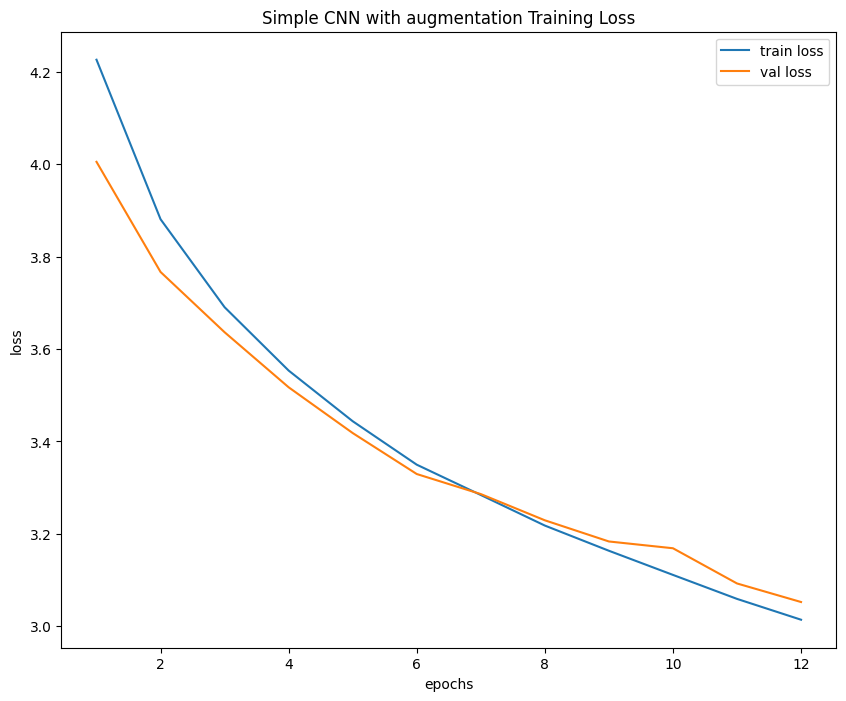

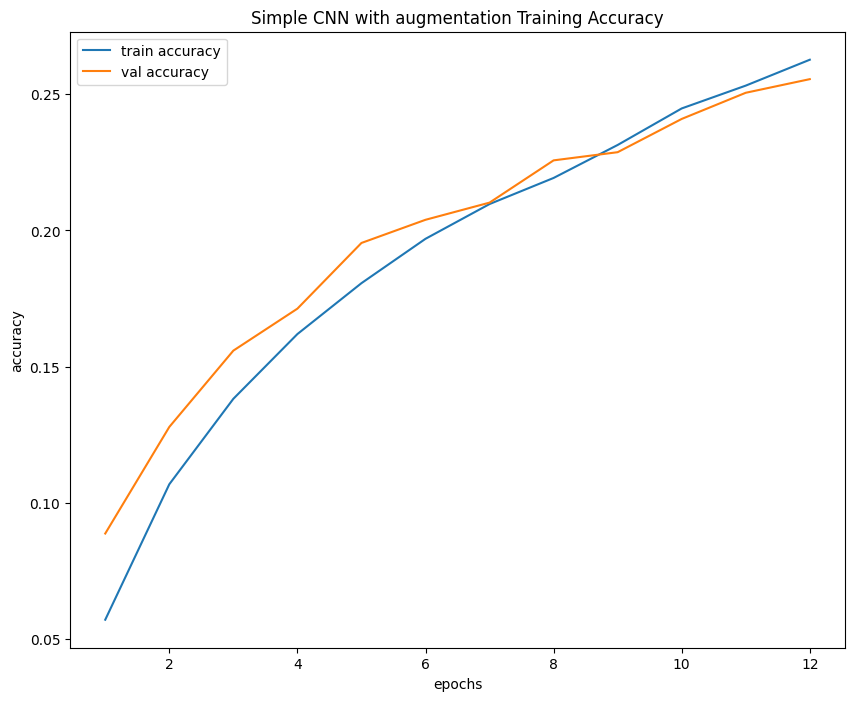

In [48]:
ds_train_aug, ds_test = loading_cifar100_dataset(
    train_transform=torchvision.transforms.Compose([
        torchvision.transforms.RandomCrop(32, padding=4),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        torchvision.transforms.RandomRotation(10),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
        torchvision.transforms.RandomErasing(p=0.1),
]),
    test_transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    ])
)

train_loader_aug, val_loader_aug, _ = make_loaders(
    ds_train_aug,
    ds_test,
)

cnn_simple_aug = CNNSimple(num_classes=len(class_names)).to(device=device)
res_c2 = run_experiment(
    "C2", 
    cnn_simple_aug, 
    train_loader_aug, 
    val_loader_aug, 
    criterion, 
    dataset='cifar100',
    model_name="simple_cnn",
    notes="with augmentation",
    lr=1e-4
)

plot_history(res_c2["history"], title="Simple CNN with augmentation")

Files already downloaded and verified
Files already downloaded and verified

Experiment C3 | lr=0.001, weight_decay=0.0, epochs=12
Trainable parameters: 51300
Epochs: 01/12, time: 32.6s | Train Loss: 3.6867, train Acc: 0.1688 | Val Loss: 3.3439, val Acc: 0.2344
Epochs: 02/12, time: 32.0s | Train Loss: 3.3210, train Acc: 0.2238 | Val Loss: 3.3694, val Acc: 0.2338
Epochs: 03/12, time: 30.0s | Train Loss: 3.2570, train Acc: 0.2334 | Val Loss: 3.3432, val Acc: 0.2338
Epochs: 04/12, time: 31.1s | Train Loss: 3.2165, train Acc: 0.2417 | Val Loss: 3.3606, val Acc: 0.2436
Epochs: 05/12, time: 29.7s | Train Loss: 3.1978, train Acc: 0.2420 | Val Loss: 3.3133, val Acc: 0.2407
Epochs: 06/12, time: 29.0s | Train Loss: 3.1722, train Acc: 0.2470 | Val Loss: 3.3581, val Acc: 0.2416
Epochs: 07/12, time: 29.1s | Train Loss: 3.1731, train Acc: 0.2497 | Val Loss: 3.3483, val Acc: 0.2451
Epochs: 08/12, time: 28.5s | Train Loss: 3.1618, train Acc: 0.2515 | Val Loss: 3.3221, val Acc: 0.2539
Epochs: 09/12, ti

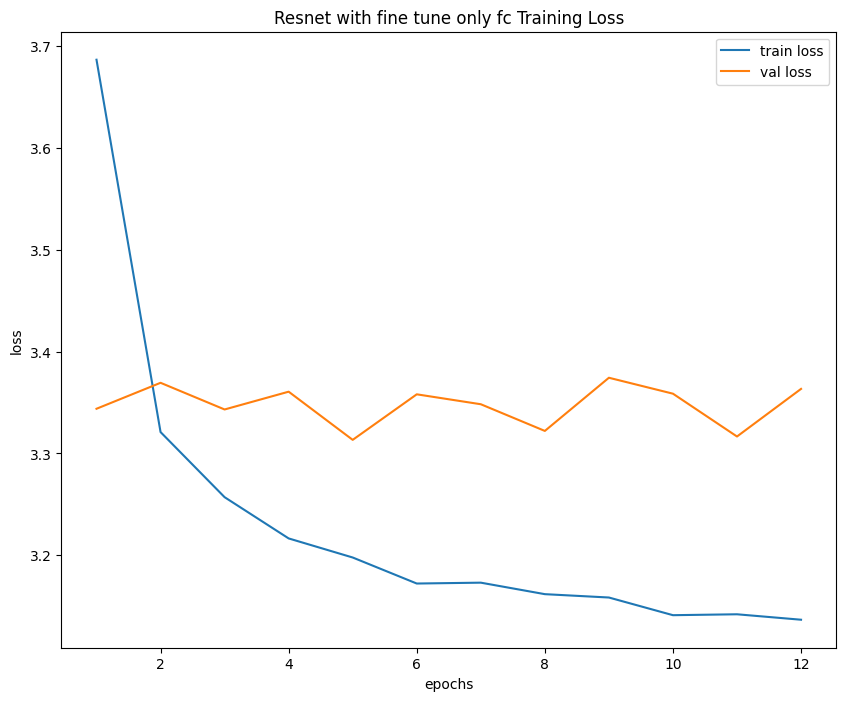

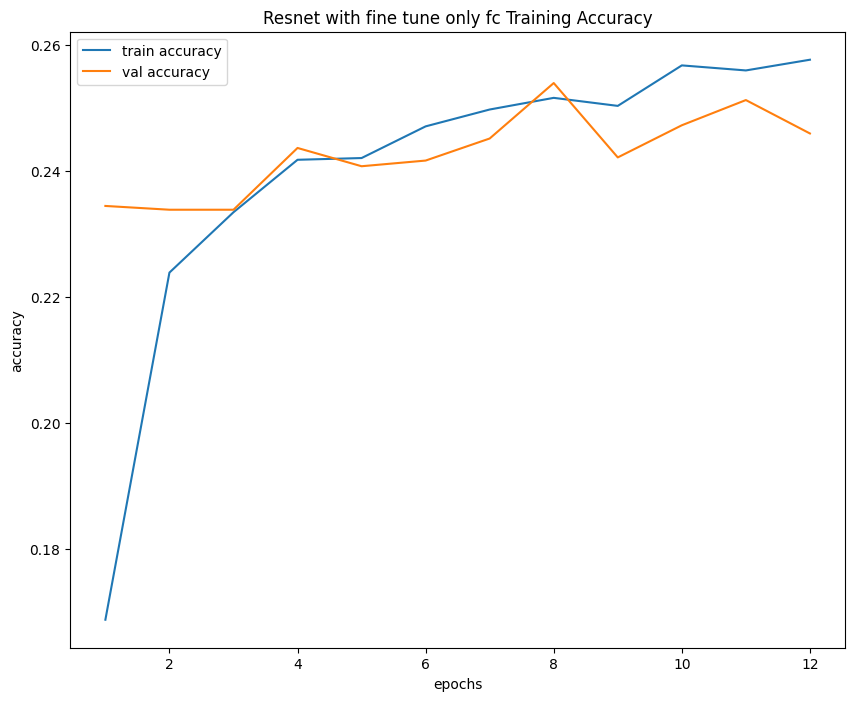

In [41]:
ds_train_for_resnet, ds_test_for_resnet = loading_cifar100_dataset(
    train_transform=torchvision.transforms.Compose([
        torchvision.transforms.Resize((224, 224)),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    ]),
    test_transform=torchvision.transforms.Compose([
        torchvision.transforms.Resize((224, 224)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    ])
)

train_loader_resnet, val_loader_resnet, test_loader_resnet = make_loaders(
    ds_train_for_resnet,
    ds_test_for_resnet,
)

model_c3 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT).to(device=device)
model_c3.fc = torch.nn.Linear(in_features=model_c3.fc.in_features, out_features=len(class_names))

model_c3.requires_grad_(False)
model_c3.fc.requires_grad_(True)

res_c3 = run_experiment(
    "C3", 
    model_c3, 
    train_loader, 
    val_loader, 
    criterion,
    dataset='cifar100',
    model_name="resnet_18",
    notes="with finetune only fc",
)

plot_history(res_c3["history"], title="Resnet with fine tune only fc")


Experiment C4 | lr=0.001, weight_decay=0.0, epochs=12
Trainable parameters: 8445028
Epochs: 01/12, time: 70.5s | Train Loss: 1.8859, train Acc: 0.4810 | Val Loss: 1.4523, val Acc: 0.5881
Epochs: 02/12, time: 67.8s | Train Loss: 1.2159, train Acc: 0.6438 | Val Loss: 1.2672, val Acc: 0.6417
Epochs: 03/12, time: 68.2s | Train Loss: 0.9388, train Acc: 0.7195 | Val Loss: 1.2405, val Acc: 0.6555
Epochs: 04/12, time: 69.0s | Train Loss: 0.7361, train Acc: 0.7738 | Val Loss: 1.2043, val Acc: 0.6760
Epochs: 05/12, time: 68.8s | Train Loss: 0.5612, train Acc: 0.8255 | Val Loss: 1.3027, val Acc: 0.6691
Epochs: 06/12, time: 68.8s | Train Loss: 0.4526, train Acc: 0.8579 | Val Loss: 1.2689, val Acc: 0.6848
Epochs: 07/12, time: 69.3s | Train Loss: 0.3474, train Acc: 0.8883 | Val Loss: 1.4317, val Acc: 0.6678
Epochs: 08/12, time: 70.0s | Train Loss: 0.3002, train Acc: 0.9054 | Val Loss: 1.4330, val Acc: 0.6867
Epochs: 09/12, time: 69.6s | Train Loss: 0.2509, train Acc: 0.9210 | Val Loss: 1.4877, val 

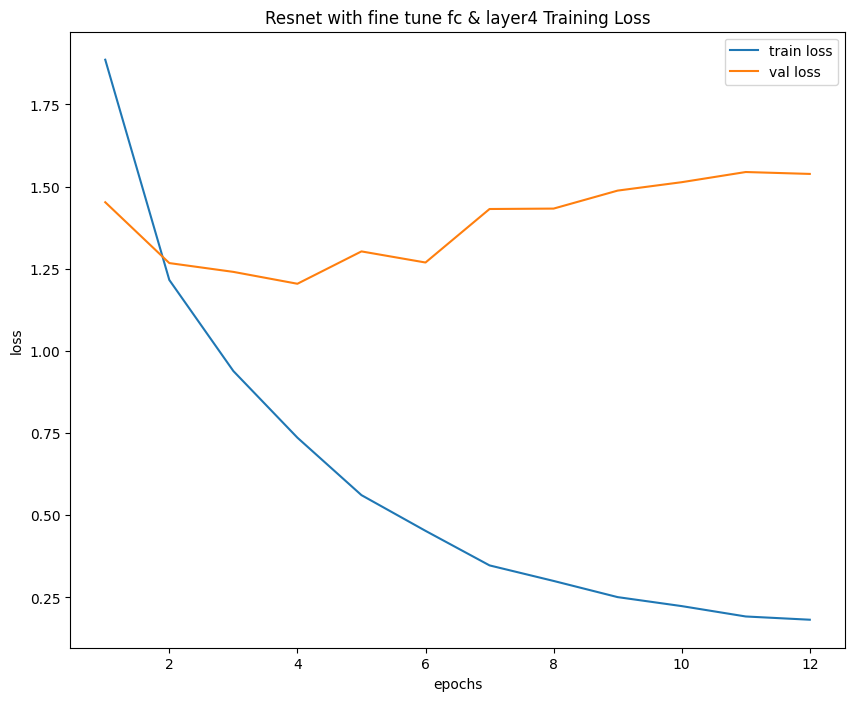

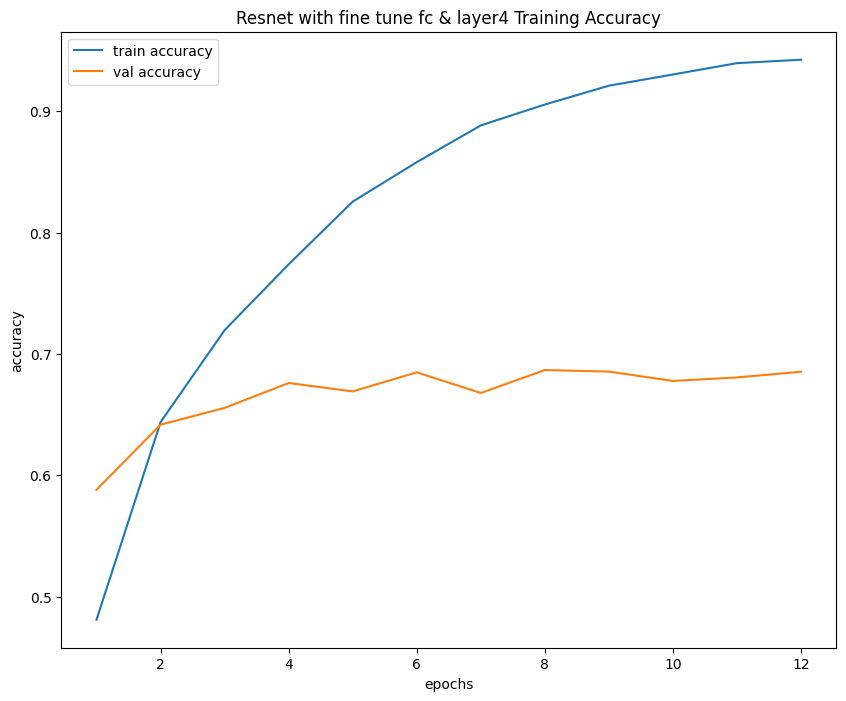

In [42]:
model_c4 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
model_c4.fc = torch.nn.Linear(in_features=model_c4.fc.in_features, out_features=len(class_names))

model_c4.requires_grad_(False)
model_c4.layer4.requires_grad_(True)
model_c4.fc.requires_grad_(True)

res_c4 = run_experiment(
    "C4",
    model_c4,
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    dataset='cifar100',
    model_name="resnet_18",
    notes="with finetune fc and layer4",
)

plot_history(res_c4['history'], title="Resnet with fine tune fc & layer4")

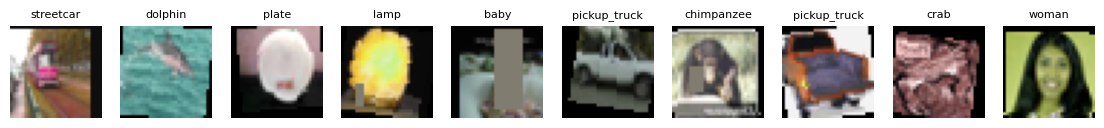

In [43]:
show_images(train_loader_aug, n=10, path_save="./artifacts/figures/augmentations_preview.png")

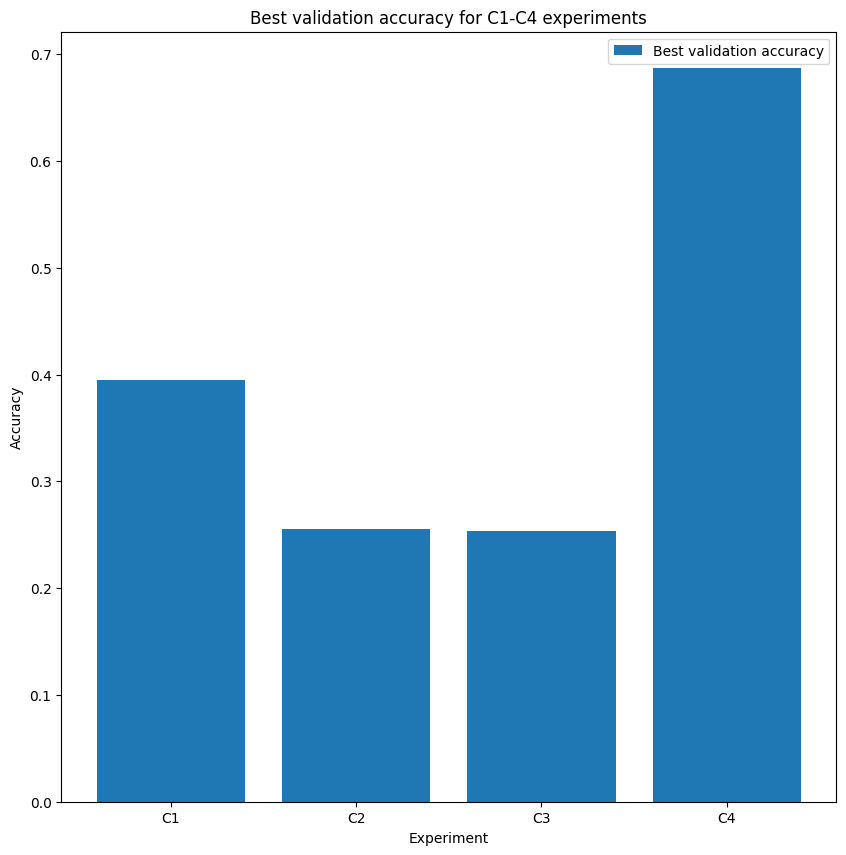

In [49]:
best_val_acc = [res_c1['best_val_acc'], res_c2['best_val_acc'], res_c3['best_val_acc'], res_c4['best_val_acc']]
experiment_names = ["C1", "C2", "C3", "C4"]

plt.figure(figsize=(10, 10))
plt.bar(experiment_names, best_val_acc, label="Best validation accuracy")
plt.title("Best validation accuracy for C1-C4 experiments")
plt.xlabel("Experiment")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(False)
plt.savefig("./artifacts/figures/classification_compare.png")
plt.show()

In [60]:
res_c1['test_accuracy'] = 0.0
res_c2['test_accuracy'] = 0.0
res_c3['test_accuracy'] = 0.0

test_loss, test_acc = evaluate(model_c4, test_loader_resnet, criterion)

res_c4['test_accuracy'] = test_acc

res_c1['seed'], res_c2['seed'], res_c3['seed'], res_c4['seed'] = [42] * 4
res_c1['task'], res_c2['task'], res_c3['task'], res_c4['task'] = ['classification'] * 4

In [59]:
res_c1

{'experiment_id': 'C1',
 'model': CNNSimple(
   (features): Sequential(
     (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (4): ReLU()
     (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (7): ReLU()
     (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=2048, out_features=256, bias=True)
     (2): ReLU()
     (3): Linear(in_features=256, out_features=100, bias=True)
   )
 ),
 'best_val_acc': 0.3946,
 'history': {'train_acc': [0.14285,
   0.28265,
   0.36555,
   0.429475,
   0.4767,
   0.525175,
   0.570275,
   0.609025,
   0.64415,
   0

In [64]:
RUNS = save_to_runs(res_c1, RUNS)
RUNS = save_to_runs(res_c2, RUNS)
RUNS = save_to_runs(res_c3, RUNS)
RUNS = save_to_runs(res_c4, RUNS)

In [65]:
RUNS

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,notes,best_val_acc,test_acc
0,C1,classification,cifar100,42,simple_cnn,Adam,0.0010,12,NaN,0.0000,None,0.3946,0.0000
1,C2,classification,cifar100,42,simple_cnn,Adam,0.0001,12,NaN,0.0000,with augmentation,0.2555,0.0000
2,C3,classification,cifar100,42,resnet_18,Adam,0.0010,12,NaN,0.0000,with finetune only fc,0.2539,0.0000
3,C4,classification,cifar100,42,resnet_18,Adam,0.0010,12,NaN,0.6872,with finetune fc and layer4,0.6867,0.6872
4,C1,classification,cifar100,42,simple_cnn,Adam,0.0010,12,NaN,0.0000,None,0.3946,0.0000
5,C2,classification,cifar100,42,simple_cnn,Adam,0.0001,12,NaN,0.0000,with augmentation,0.2555,0.0000
6,C3,classification,cifar100,42,resnet_18,Adam,0.0010,12,NaN,0.0000,with finetune only fc,0.2539,0.0000
7,C4,classification,cifar100,42,resnet_18,Adam,0.0010,12,NaN,0.6872,with finetune fc and layer4,0.6867,0.6872


In [67]:
save_runs(RUNS, './artifacts/runs.csv')

In [68]:
torch.save(model_c4.state_dict(), './artifacts/best_classifier.pt')

In [81]:
best_res = copy.deepcopy(res_c4)
best_res['transformers'] = {
    "resize": 224,
    "normalize": True,
    "to_tensor": True
}

filter_fields = [
    'task', 'model', 'test_accuracy', 'history', 'best_val_accuracy',
]
[best_res.pop(x, None) for x in filter_fields]

save_json(best_res, './artifacts/best_classifier_config.json')

In [85]:
res_c4

{'experiment_id': 'C4',
 'best_val_acc': 0.6867,
 'optimizer': 'Adam',
 'lr': 0.001,
 'epochs_trained': 12,
 'dataset': 'cifar100',
 'model_summary': 'resnet_18',
 'notes': 'with finetune fc and layer4',
 'test_acc': 0.6872,
 'seed': 42,
 'transformers': {'resize': 224, 'normalize': True, 'to_tensor': True}}

In [84]:
plot_best_history(
    res_c4["history"],
    title="ResNet18 fine-tune fc & layer4",
    save_path="figures/classification_curves_best.png",
)

KeyError: 'history'